In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [108]:
df=pd.read_csv('ecommerce_sales_data (2).csv')
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [110]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [111]:
df.drop(columns='Order Date',inplace=True)

In [112]:
df.isnull().sum()

Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [113]:
x=df.iloc[:,:-1]
y=df['Profit']


In [114]:
df.head()

,Product Name,Category,Region,Quantity,Sales,Profit
0,Printer,Office,North,4,3640,348.93
1,Mouse,Accessories,East,7,1197,106.53
2,Tablet,Electronics,South,5,5865,502.73
3,Mouse,Accessories,South,2,786,202.87
4,Mouse,Accessories,West,1,509,103.28


EDA Processing

Outlier handling

In [115]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Quantity', 'Sales', 'Profit'], dtype='object')


In [116]:
outlier_count = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_count[col] = outliers.shape[0]

outlier_df = pd.DataFrame.from_dict(outlier_count, orient='index', columns=['Outlier_Count'])
print(outlier_df)

          Outlier_Count
Quantity              0
Sales                35
Profit              184


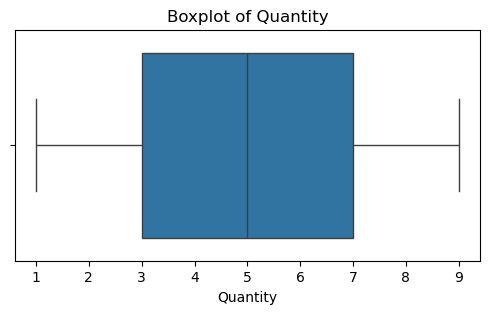

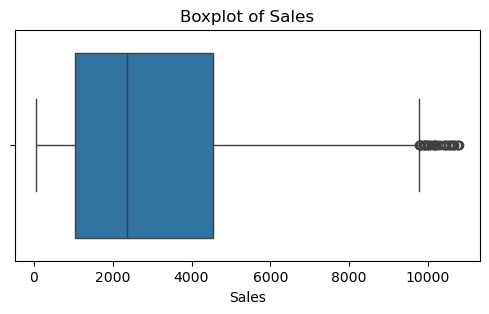

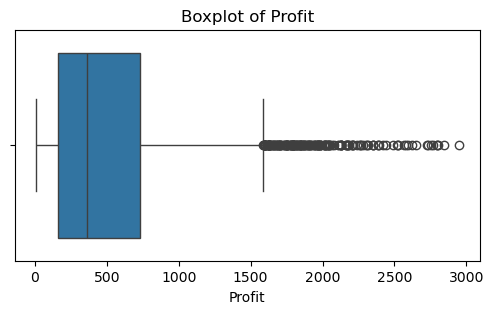

In [117]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [118]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)


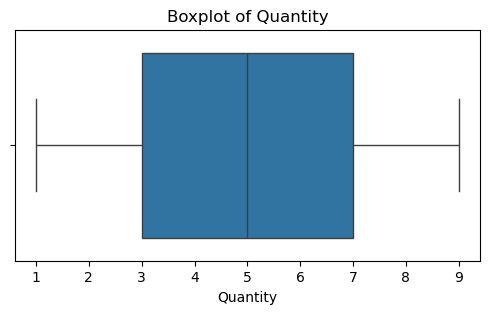

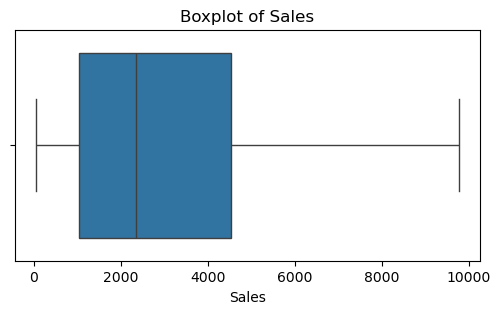

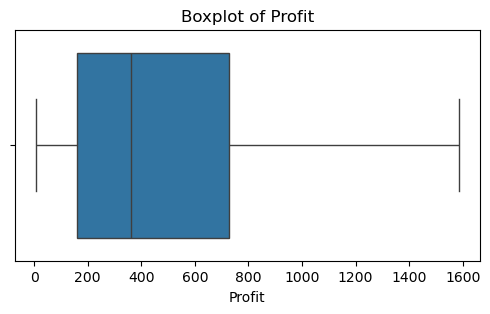

In [119]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [120]:
df.head()

,Product Name,Category,Region,Quantity,Sales,Profit
0,Printer,Office,North,4,3640.0,348.93
1,Mouse,Accessories,East,7,1197.0,106.53
2,Tablet,Electronics,South,5,5865.0,502.73
3,Mouse,Accessories,South,2,786.0,202.87
4,Mouse,Accessories,West,1,509.0,103.28


In [121]:
#skewness removal
from scipy.stats import skew

Quantity
0.029303653819268572


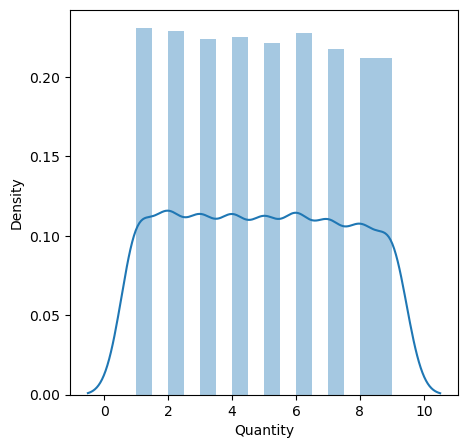

Sales
0.9371526222846962


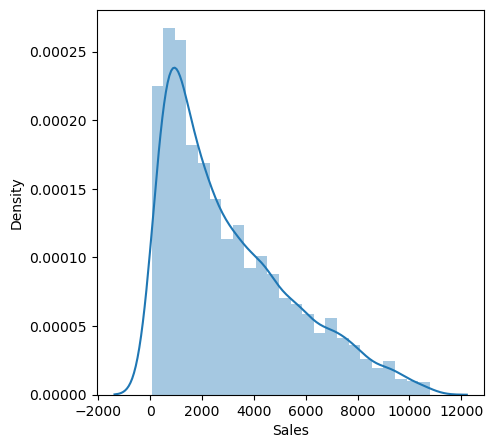

In [122]:

col=x.select_dtypes('int','float').columns
for i in x[col]:
    print(i)
    print(skew(x[i]))
    plt.figure(figsize=(5,5))
    sns.distplot(x[i])
    plt.show()

In [123]:
x['Sales'] = np.sqrt(x['Sales'])

In [124]:
skew(x['Sales'])

np.float64(0.27125385374914335)

<Axes: xlabel='Sales', ylabel='Density'>

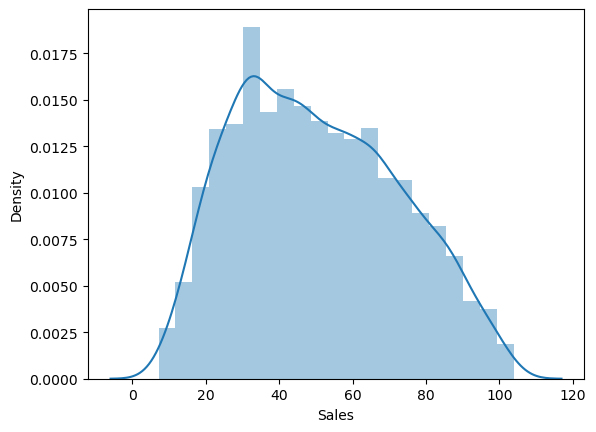

In [125]:
sns.distplot(x['Sales'])

In [126]:
pd.concat([x,y],axis=1).corr(numeric_only=True).style.background_gradient()

,Quantity,Sales,Profit
Quantity,1.000000,0.678042,0.560651
Sales,0.678042,1.000000,0.813250
Profit,0.560651,0.813250,1.000000


Encoding

In [127]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer

In [128]:
cat_col=x.select_dtypes('object').columns
cat_col
num_col=x.select_dtypes(int).columns

In [129]:
ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[cat_col])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_col),
    index=df.index
)

# Drop old categorical columns
df = df.drop(columns=cat_col)

# Concatenate encoded columns
df = pd.concat([encoded_df,df], axis=1)

In [130]:
x=df.iloc[:,:-1]
y=df['Profit']

In [131]:
#Scaling
from sklearn.preprocessing import StandardScaler
mn=StandardScaler()
x.iloc[:,:]=mn.fit_transform(x.iloc[:,:])
x.head()

,Product Name_Camera,Product Name_Headphones,Product Name_Keyboard,Product Name_Laptop,Product Name_Monitor,Product Name_Mouse,Product Name_Printer,Product Name_Smartphone,Product Name_Smartwatch,Product Name_Tablet,Category_Accessories,Category_Electronics,Category_Office,Region_East,Region_North,Region_South,Region_West,Quantity,Sales
0,-0.34017,-0.327482,-0.333862,-0.325875,-0.340693,-0.331744,2.967140,-0.322647,-0.34017,-0.333333,-0.816983,-0.995439,2.967140,-0.571192,1.754780,-0.580869,-0.587468,-0.361757,0.245970
1,-0.34017,-0.327482,-0.333862,-0.325875,-0.340693,3.014375,-0.337025,-0.322647,-0.34017,-0.333333,1.224016,-0.995439,-0.337025,1.750726,-0.569872,-0.580869,-0.587468,0.803054,-0.760978
2,-0.34017,-0.327482,-0.333862,-0.325875,-0.340693,-0.331744,-0.337025,-0.322647,-0.34017,3.000000,-0.816983,1.004582,-0.337025,-0.571192,-0.569872,1.721557,-0.587468,0.026513,1.163064
3,-0.34017,-0.327482,-0.333862,-0.325875,-0.340693,3.014375,-0.337025,-0.322647,-0.34017,-0.333333,1.224016,-0.995439,-0.337025,-0.571192,-0.569872,1.721557,-0.587468,-1.138297,-0.930383
4,-0.34017,-0.327482,-0.333862,-0.325875,-0.340693,3.014375,-0.337025,-0.322647,-0.34017,-0.333333,1.224016,-0.995439,-0.337025,-0.571192,-0.569872,-0.580869,1.702219,-1.526567,-1.044556


Split data

In [132]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.30,random_state=0)


Multiple regression

In [133]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

#train the model
lr.fit(xtrain,ytrain)

#predict the obs
ypred=lr.predict(xtest)

In [134]:
lr.coef_

array([ 5.47251995e+00,  1.83552790e+00, -4.27996809e+00,  2.13728134e+00,
        2.15213806e+00,  2.82164174e+00, -1.51723085e+00, -3.77828494e+00,
        9.03847790e-02, -5.06626454e+00,  1.54602236e+00, -5.96597961e-01,
       -1.51723085e+00,  1.46552751e+00,  3.10476125e+00, -2.61500589e+00,
       -1.90271088e+00,  1.23477607e+01,  3.59743925e+02])

In [135]:
lr.intercept_

np.float64(502.8897388157163)

Evaluation metrics

In [136]:
from sklearn.metrics import r2_score
r2_score(ytest,ypred)

0.711107316657945

In [137]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_absolute_error(ytest,ypred))
print(mean_squared_error(ytest,ypred))
print(np.sqrt(mean_squared_error(ytest,ypred)))

176.93233299389425
60367.02238536586
245.69701338308096


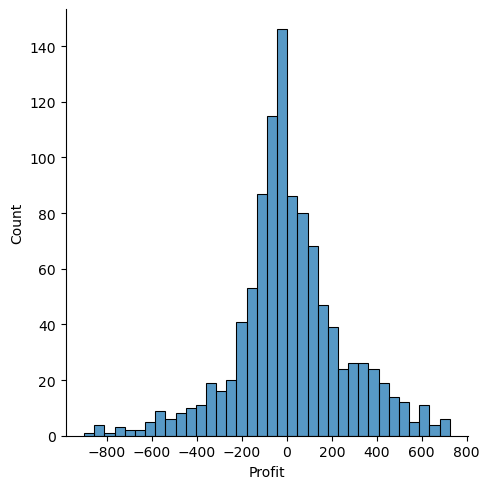

In [138]:
sns.displot(ytest-ypred)

KNN

In [139]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=6)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [140]:
r2_score(ytest,ypred)

0.6710586359300519

HPT

In [141]:
ac_list=[]
for i in range(1,100):
    knn=KNeighborsRegressor(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    ypred=knn.predict(xtest)
    ac=r2_score(ytest,ypred)
    ac_list.append(ac)

In [142]:
ac_list

[0.48325267296352126,
 0.6207174180494954,
 0.6515921959603204,
 0.6686879384440398,
 0.6686690926181003,
 0.6710586359300519,
 0.6719255352171208,
 0.6682044750184778,
 0.662714156757777,
 0.6598213799904121,
 0.6547288503466593,
 0.649891021566492,
 0.6451144999669097,
 0.6386234969663476,
 0.6318075223755777,
 0.6233879903981316,
 0.6174204765000636,
 0.6083163718571631,
 0.6000203428295113,
 0.5902722484053561,
 0.5815304448371602,
 0.5709113586342294,
 0.5600585310136819,
 0.5537168578597835,
 0.5448345688562466,
 0.5351960232810986,
 0.5257189748212069,
 0.5149450548078343,
 0.5057883397505842,
 0.4958069349563109,
 0.4855780368157895,
 0.4752414841270801,
 0.46517893887129647,
 0.4557685595341934,
 0.44483808812062275,
 0.4365868314404554,
 0.429226375086844,
 0.4206965228175328,
 0.41194530390248896,
 0.40214999291798514,
 0.3961391929758725,
 0.38864375643689775,
 0.3821141883464526,
 0.37557388787755663,
 0.3706938419614272,
 0.3661622827202209,
 0.3624557606984725,
 0.359869

Rebuild Model taking k=29

In [143]:
knn=KNeighborsRegressor(n_neighbors=29)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [144]:
print(r2_score(ytest,ypred))

0.5057883397505842


SVM

In [145]:
from sklearn.svm import SVR


In [146]:
svm=SVR()

In [147]:
def mymodel(model):
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    print(r2_score(ytest,ypred))
    return model

In [148]:
mymodel(knn)

0.5057883397505842


,n_neighbors,29
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [149]:
mymodel(svm)

-0.00216384080400589


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [150]:
svm=SVR(kernel='linear')
mymodel(svm)

0.7039294100861797


,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [151]:
svm=SVR(kernel='poly')
mymodel(svm)

-0.00762991592771467


,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [152]:
svm=SVR(kernel='sigmoid')
mymodel(svm)

0.20072947389116313


,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


Hypertuning

In [153]:
from sklearn.model_selection import GridSearchCV

In [154]:
param_grid={'C':[10,20],'gamma':[10,20],'kernel':['linear']}

In [155]:
gs=GridSearchCV(svm,param_grid,verbose=3)
gs.fit(xtrain,ytrain)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END .....C=10, gamma=10, kernel=linear;, score=0.670 total time=   0.2s
[CV 2/5] END .....C=10, gamma=10, kernel=linear;, score=0.745 total time=   0.2s
[CV 3/5] END .....C=10, gamma=10, kernel=linear;, score=0.619 total time=   0.2s
[CV 4/5] END .....C=10, gamma=10, kernel=linear;, score=0.697 total time=   0.2s
[CV 5/5] END .....C=10, gamma=10, kernel=linear;, score=0.739 total time=   0.1s
[CV 1/5] END .....C=10, gamma=20, kernel=linear;, score=0.670 total time=   0.1s
[CV 2/5] END .....C=10, gamma=20, kernel=linear;, score=0.745 total time=   0.1s
[CV 3/5] END .....C=10, gamma=20, kernel=linear;, score=0.619 total time=   0.1s
[CV 4/5] END .....C=10, gamma=20, kernel=linear;, score=0.697 total time=   0.2s
[CV 5/5] END .....C=10, gamma=20, kernel=linear;, score=0.739 total time=   0.1s
[CV 1/5] END .....C=20, gamma=10, kernel=linear;, score=0.668 total time=   0.1s
[CV 2/5] END .....C=20, gamma=10, kernel=linear;,

,estimator,SVR(kernel='sigmoid')
,param_grid,"{'C': [10, 20], 'gamma': [10, 20], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [156]:
gs.best_params_

{'C': 10, 'gamma': 10, 'kernel': 'linear'}

In [157]:
gs.best_estimator_

,kernel,'linear'
,degree,3
,gamma,10
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [158]:
svm=gs.best_estimator_
svm.fit(xtrain,ytrain)
ypred=svm.predict(xtest)

In [159]:
r2_score(ytest,ypred)

0.7137246742971974

Decision Tree

In [160]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

In [161]:
dt=DecisionTreeRegressor()

In [162]:
mymodel(dt)

0.4606144403930287


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [163]:
print(dt.score(xtrain,ytrain))
print(dt.score(xtest,ytest))

0.9995399556387302
0.4606144403930287


Pruning Techniques--> 1.Max_depth 2.min_samples_leaf 3.min_samples_split

In [164]:
for i in range(1,30):
    dt1=DecisionTreeRegressor(max_depth=i)
    dt1.fit(xtrain,ytrain)
    ypred=dt1.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Max_depth{i} accuracy{ac}")

Max_depth1 accuracy0.5157486980871451
Max_depth2 accuracy0.6640229532761853
Max_depth3 accuracy0.7053437619156488
Max_depth4 accuracy0.7051069437833752
Max_depth5 accuracy0.6947569269418366
Max_depth6 accuracy0.6784557693241693
Max_depth7 accuracy0.6664850425081208
Max_depth8 accuracy0.6401343161449966
Max_depth9 accuracy0.6379198692617968
Max_depth10 accuracy0.6173047725082104
Max_depth11 accuracy0.5894638612670662
Max_depth12 accuracy0.5795244420387584
Max_depth13 accuracy0.562003858532243
Max_depth14 accuracy0.5310985631912133
Max_depth15 accuracy0.5007307141487223
Max_depth16 accuracy0.4840940943229636
Max_depth17 accuracy0.49614847053742306
Max_depth18 accuracy0.49049294352074946
Max_depth19 accuracy0.48383653966583184
Max_depth20 accuracy0.47246327230491125
Max_depth21 accuracy0.47399938446115664
Max_depth22 accuracy0.4728388535846776
Max_depth23 accuracy0.46863933975230165
Max_depth24 accuracy0.4640726137052794
Max_depth25 accuracy0.46089797219813733
Max_depth26 accuracy0.454884

In [165]:
dt2=DecisionTreeRegressor(max_depth=3)
mymodel(dt2)

0.705343761915649


,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [166]:
#check overfitting
print(dt2.score(xtrain,ytrain))
print(dt2.score(xtest,ytest))

0.7077270396342852
0.705343761915649


In [167]:
#min_samples_leaf
for i in range(1,40):
    dt3=DecisionTreeRegressor(min_samples_leaf=i)
    dt3.fit(xtrain,ytrain)
    ypred=dt3.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Min_samples_leaf{i} accuracy{ac}")

Min_samples_leaf1 accuracy0.4707487559402639
Min_samples_leaf2 accuracy0.5256652653683609
Min_samples_leaf3 accuracy0.5743429516396118
Min_samples_leaf4 accuracy0.6107588752606725
Min_samples_leaf5 accuracy0.631705867911011
Min_samples_leaf6 accuracy0.6284931584045561
Min_samples_leaf7 accuracy0.6391718468606703
Min_samples_leaf8 accuracy0.6543922470191166
Min_samples_leaf9 accuracy0.662810427948785
Min_samples_leaf10 accuracy0.6734583450588498
Min_samples_leaf11 accuracy0.6720005054841427
Min_samples_leaf12 accuracy0.6713406471036596
Min_samples_leaf13 accuracy0.6798541107661521
Min_samples_leaf14 accuracy0.6801325938998939
Min_samples_leaf15 accuracy0.6863845440138872
Min_samples_leaf16 accuracy0.6830092099764895
Min_samples_leaf17 accuracy0.6825892939062576
Min_samples_leaf18 accuracy0.6839385763340928
Min_samples_leaf19 accuracy0.6904606720117815
Min_samples_leaf20 accuracy0.6894179912043239
Min_samples_leaf21 accuracy0.6890504688628795
Min_samples_leaf22 accuracy0.6938999079878018

In [168]:
dt4=DecisionTreeRegressor(min_samples_leaf=40)
mymodel(dt4)

0.7142298897270545


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,40
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [169]:
print(dt4.score(xtrain,ytrain))
print(dt4.score(xtest,ytest))

0.7225486398922367
0.7142298897270545


In [170]:

#min_samples_split
for i in range(2,30):
    dt5=DecisionTreeRegressor(min_samples_split=i)
    dt5.fit(xtrain,ytrain)
    ypred=dt5.predict(xtest)

    ac=r2_score(ytest,ypred)
    print(f"Min_samples_split{i} accuracy{ac}")

Min_samples_split2 accuracy0.4685844383447184
Min_samples_split3 accuracy0.4821938449386496
Min_samples_split4 accuracy0.5122115069556443
Min_samples_split5 accuracy0.5205397176554679
Min_samples_split6 accuracy0.5395521738206329
Min_samples_split7 accuracy0.545847512136252
Min_samples_split8 accuracy0.5558555658420181
Min_samples_split9 accuracy0.567566061655506
Min_samples_split10 accuracy0.5789799199005093
Min_samples_split11 accuracy0.5862266178312712
Min_samples_split12 accuracy0.5945820378293938
Min_samples_split13 accuracy0.6095550804789722
Min_samples_split14 accuracy0.6137217482979396
Min_samples_split15 accuracy0.6199947793853678
Min_samples_split16 accuracy0.6208670009103848
Min_samples_split17 accuracy0.6208530540962446
Min_samples_split18 accuracy0.6212335466243144
Min_samples_split19 accuracy0.6243768053074534
Min_samples_split20 accuracy0.6261001364292672
Min_samples_split21 accuracy0.6279666728864024
Min_samples_split22 accuracy0.6274050843263483
Min_samples_split23 acc

In [171]:
dt6=DecisionTreeRegressor(min_samples_split=300)
mymodel(dt6)

0.711741624185243


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,300
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [172]:
print(dt6.score(xtrain,ytrain))
print(dt6.score(xtest,ytest))

0.7133221144398282
0.711741624185243


Ensemble Learning-->bagging and boosting

In [173]:
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor

bagging

In [174]:
bg=BaggingRegressor(LinearRegression())

In [175]:
mymodel(bg)

0.7108783306647013


,estimator,LinearRegression()
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [176]:
rf=RandomForestRegressor()
mymodel(rf)

0.6925652608290012


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [177]:
from sklearn.ensemble import VotingRegressor

In [178]:
model=[]
model.append(('LR',LinearRegression()))
model.append(('DT',DecisionTreeRegressor()))

In [179]:
vr=VotingRegressor(estimators=model)
mymodel(vr)

0.6605911160452542


,estimators,"[('LR', ...), ('DT', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,criterion,'squared_error'
,splitter,'best'


Boosting

In [180]:
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor

In [181]:
ada=AdaBoostRegressor()
mymodel(ada)

0.701068698690474


,estimator,None
,n_estimators,50
,learning_rate,1.0
,loss,'linear'
,random_state,None


In [182]:
gb=GradientBoostingRegressor()
mymodel(gb)

0.7112187575157606


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [183]:
from xgboost import XGBRegressor

In [184]:
xgb=XGBRegressor()
mymodel(xgb)

0.6444922582948562


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
